**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot parity plots 
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in LightBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Create dataframe with the main indiators of models' performance

All models are trained with RDKit descriptors

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

First, let's import datasets and y-target, created earlier:

In [2]:
with open ('Features_RDKit/rdkit_descs.pickle', 'rb') as inp:
    rdkit_descs = pickle.load(inp)

Then we load all data files and create Scores dictionaries

In [3]:
data_anionic = pd.read_csv('Data/Data_anionic.csv')
target_anionic = data_anionic['Cc ']

data_cationic = pd.read_csv('Data/Data_cationic.csv')
target_cationic = data_cationic['Cc ']

data_extended = pd.read_csv('Data/Data_extended.csv')
target_extended = data_extended['Cc ']

data_non_ionic = pd.read_csv('Data/Data_non_ionic.csv')
target_non_ionic = data_non_ionic['Cc ']

targets = {'RDKIt_anionic': target_anionic, 'RDKIt_non_ionic': target_non_ionic, 'RDKIt_extended':target_extended, 'RDKit_cationic': target_cationic}

In [4]:
scores_anionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_cationic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_non_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_extended = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores = {'RDKIt_anionic': scores_anionic, 'RDKit_cationic':scores_cationic, 'RDKIt_non_ionic': scores_non_ionic, 'RDKIt_extended':scores_extended}

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [5]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']

This function makes all the calculations and plotting and saves the results into *Scores* dictionary

In [6]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = rdkit_descs, targets = targets, n_iters = 50):
    fig, axes = plt.subplots(1, 4, figsize = (12,8))
    i = 0
    #Iterate through key items - names of classes of surfactants
    for key, value in descriptors_dict.items():
        target = targets[key]
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        #Objective fuction is what we optimize.  We optimize mean absolute error
        def objective(params, X, target):
            pipe = make_pipeline(StandardScaler(), estimator)
            pipe.set_params(**params)
            y_cv_pred = cross_val_predict(pipe, X, target, cv=10)
            cv_rmse = np.sqrt(root_mean_squared_error(target, y_cv_pred))
            cv_r2 = r2_score(target, y_cv_pred)
            
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'neg_mean_absolute_error')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe, 'rmse':cv_rmse, 'r2':cv_r2}
        
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  n_iters)
        print(best)
        #Get best trained model
        best_estimator  = get_best_model_from_trials(trials)['Trained_model']
      
        #Get the results of the best 5-fold cross-validation
        cv_r2 = get_best_model_from_trials(trials)['r2']
        cv_rmse = get_best_model_from_trials(trials)['rmse']
        cv_mae = get_best_model_from_trials(trials)['loss']
         #Add the CV result into scores dictionary
        scores[key]['Descriptors'].append('RDKit')
        scores[key]['R2_cv'].append(cv_r2)
        scores[key]['RMSE_cv'].append(cv_rmse)
        scores[key]['MAE_cv'].append(cv_mae)
        #fit best estimator on train set and add into scores dictionary
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        predictions_train = best_estimator.predict(X_train)
        scores[key]['Estimator'].append(estimator_name)
        scores[key]['R2_test'].append(r2_score(y_test, predictions))
        scores[key]['R2_train'].append(r2_score(y_train, predictions_train))
        
        scores[key]['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores[key]['RMSE_train'].append(root_mean_squared_error(y_train, predictions_train))

        
        scores[key]['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores[key]['MAE_train'].append(mean_absolute_error(y_train, predictions_train))
        #Make parity plot
        axes[i].plot(y_test, predictions, 'ro', label = 'Test values')
        axes[i].plot(y_train, predictions_train, 'go', label = 'Train values')
        axes[i].plot([target.min(),target.max()], [target.min(),target.max()])
        axes[i].set_title('{}'.format(key))
        axes[i].set_xlabel('True test values')
        axes[i].set_ylabel('Predicted test values')
        axes[i].legend()
        i += 1
    plt.tight_layout()
    plt.savefig('RDKit_{}_scattter.png'.format(estimator_name))

Let's  test the function with Ridge  Regression

100%|████████████████████████████████████████████████| 50/50 [00:08<00:00,  6.09trial/s, best loss: 1.4127350135774577]
{'alpha': 0.0010009642643848226, 'solver': 5}
100%|██████████████████████████████████████████████████| 50/50 [00:07<00:00,  7.05trial/s, best loss: 2.44729164564431]
{'alpha': 97.82412375078536, 'solver': 6}
100%|████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.18trial/s, best loss: 1.4445922473682906]
{'alpha': 98.77341099629008, 'solver': 3}
100%|█████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.58trial/s, best loss: 0.713735590076482]
{'alpha': 52.24983661186936, 'solver': 2}


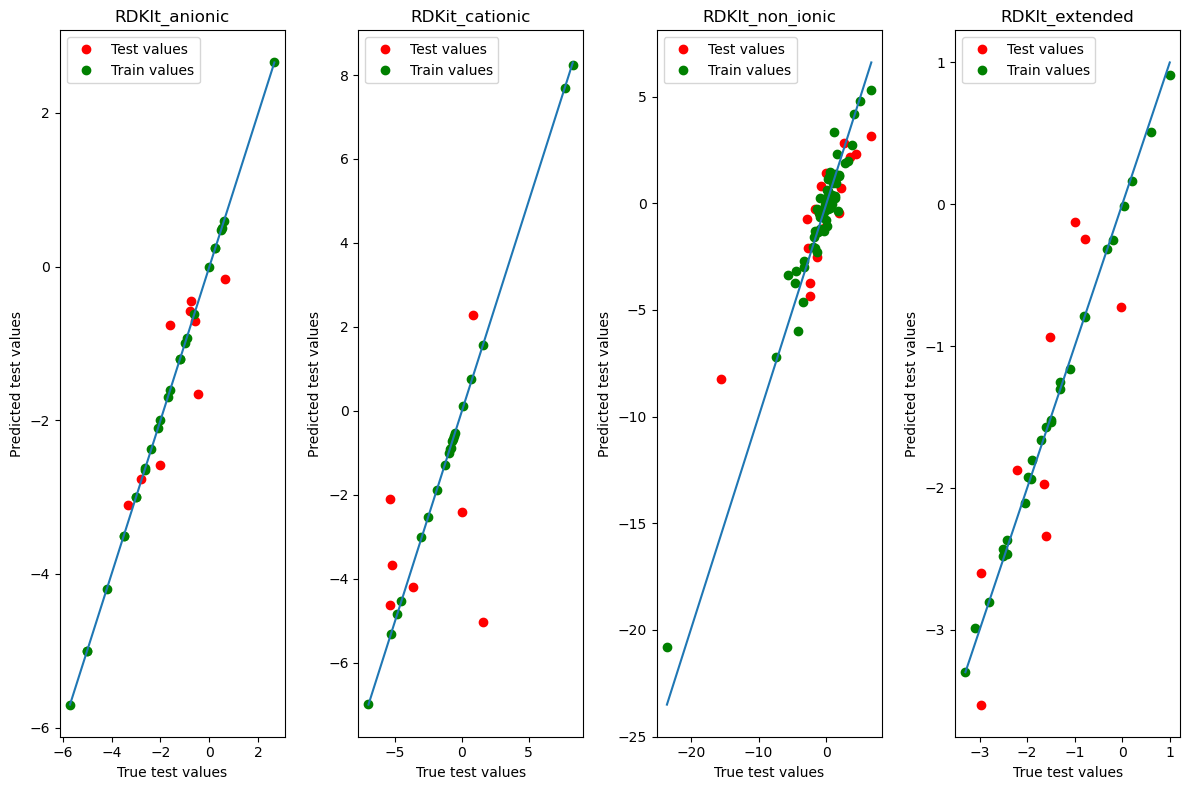

In [13]:
calculate_to_score(Ridge(max_iter = 10000), estimator_name='Linear Regression', 
                   param_grid = {'ridge__alpha':hp.loguniform(label = 'alpha', low = -4*np.log(10), high  = 2*np.log(10)),
                                'ridge__solver':hp.choice(label = 'solver', options = ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg','sag', 'saga'])})

Let's continue with other models. The first one will be
**Random Forest Classification**

In [14]:
space = {
    'randomforestregressor__max_depth': hp.randint('max_depth', 3, 15),  
    'randomforestregressor__max_features': hp.choice('max_features', [0.3, 0.5, 'sqrt', 'log2']), 
    'randomforestregressor__min_samples_split': hp.randint('min_samples_split', 5, 20),  
    'randomforestregressor__min_samples_leaf': hp.randint('min_samples_leaf', 3, 10), 
    'randomforestregressor__criterion': hp.choice('criterion', ["squared_error", "absolute_error"]), 
    'randomforestregressor__ccp_alpha': hp.uniform('ccp_alpha', 0, 0.1),  
    'randomforestregressor__n_estimators': hp.randint('n_estimators', 50, 200),  
    'randomforestregressor__bootstrap': hp.choice('bootstrap', [True]),  
    'randomforestregressor__max_samples': hp.uniform('max_samples', 0.6, 0.95)} 

100%|████████████████████████████████████████████████| 50/50 [02:11<00:00,  2.63s/trial, best loss: 1.5450235252594626]
{'bootstrap': 0, 'ccp_alpha': 0.06263398559977702, 'criterion': 1, 'max_depth': 5, 'max_features': 0, 'max_samples': 0.6037753666137429, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 104}
100%|████████████████████████████████████████████████| 50/50 [01:50<00:00,  2.22s/trial, best loss: 2.3157602130872776]
{'bootstrap': 0, 'ccp_alpha': 0.09204568111097178, 'criterion': 0, 'max_depth': 5, 'max_features': 0, 'max_samples': 0.9480116364113302, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 66}
100%|████████████████████████████████████████████████| 50/50 [02:07<00:00,  2.55s/trial, best loss: 1.5225075901862892]
{'bootstrap': 0, 'ccp_alpha': 0.016115445072149924, 'criterion': 0, 'max_depth': 5, 'max_features': 1, 'max_samples': 0.7944685879376255, 'min_samples_leaf': 7, 'min_samples_split': 8, 'n_estimators': 168}
100%|████████████████████

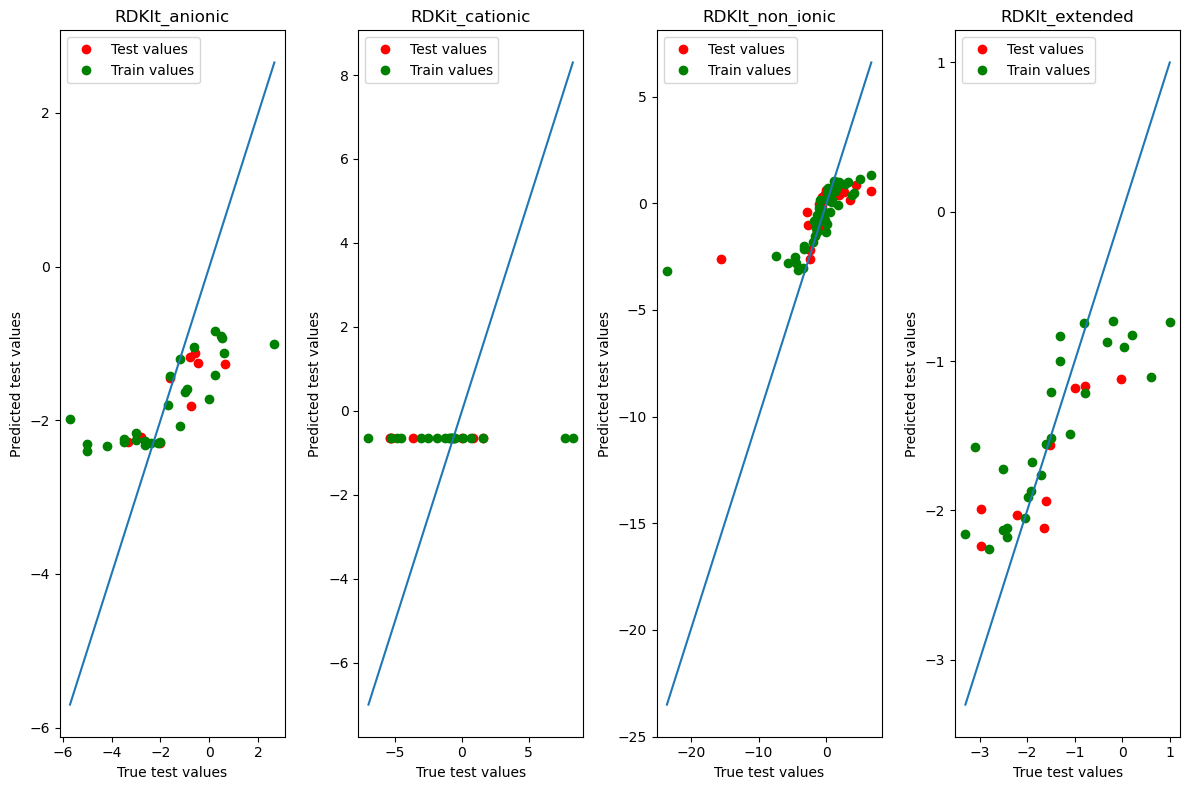

In [15]:
calculate_to_score(RandomForestRegressor(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space)
               

**LightGBM**

In [16]:
space = {'lgbmregressor__max_depth':hp.randint('max_depth', 3, 12),
        'lgbmregressor__boosting_type':hp.choice('boosting_type', ['gbdt']),
        'lgbmregressor__reg_alpha':hp.loguniform('reg_alpha', -3*np.log(10), 1*np.log(10)),
         'lgbmregressor__reg_lamdba':hp.loguniform('reg_lambda', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__learning_rate':hp.loguniform('learning_rate', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__n_estimators':hp.randint('n_estimators', 50, 300),
        'lgbmregressor__n_leaves':hp.randint('n_leaves', 10, 50),
        'lgbmregressor__min_child_samples': hp.randint('min_child_samples', 5, 30)}

100%|█████████████████████████████████████████████████| 50/50 [00:15<00:00,  3.13trial/s, best loss: 1.554996929513296]
{'boosting_type': 0, 'learning_rate': 0.04503166092908109, 'max_depth': 8, 'min_child_samples': 7, 'n_estimators': 176, 'n_leaves': 47, 'reg_alpha': 0.0011115327432179157, 'reg_lambda': 0.7202154956132945}
100%|█████████████████████████████████████████████████| 50/50 [00:10<00:00,  4.66trial/s, best loss: 2.525528159482964]
{'boosting_type': 0, 'learning_rate': 0.0018413150177033458, 'max_depth': 6, 'min_child_samples': 8, 'n_estimators': 100, 'n_leaves': 16, 'reg_alpha': 0.02124887432478203, 'reg_lambda': 0.07152949909377658}
100%|████████████████████████████████████████████████| 50/50 [00:25<00:00,  1.97trial/s, best loss: 1.4586716760808052]
{'boosting_type': 0, 'learning_rate': 0.009560116115910034, 'max_depth': 10, 'min_child_samples': 13, 'n_estimators': 215, 'n_leaves': 14, 'reg_alpha': 0.6356361142790987, 'reg_lambda': 1.1878549328357821}
100%|████████████████

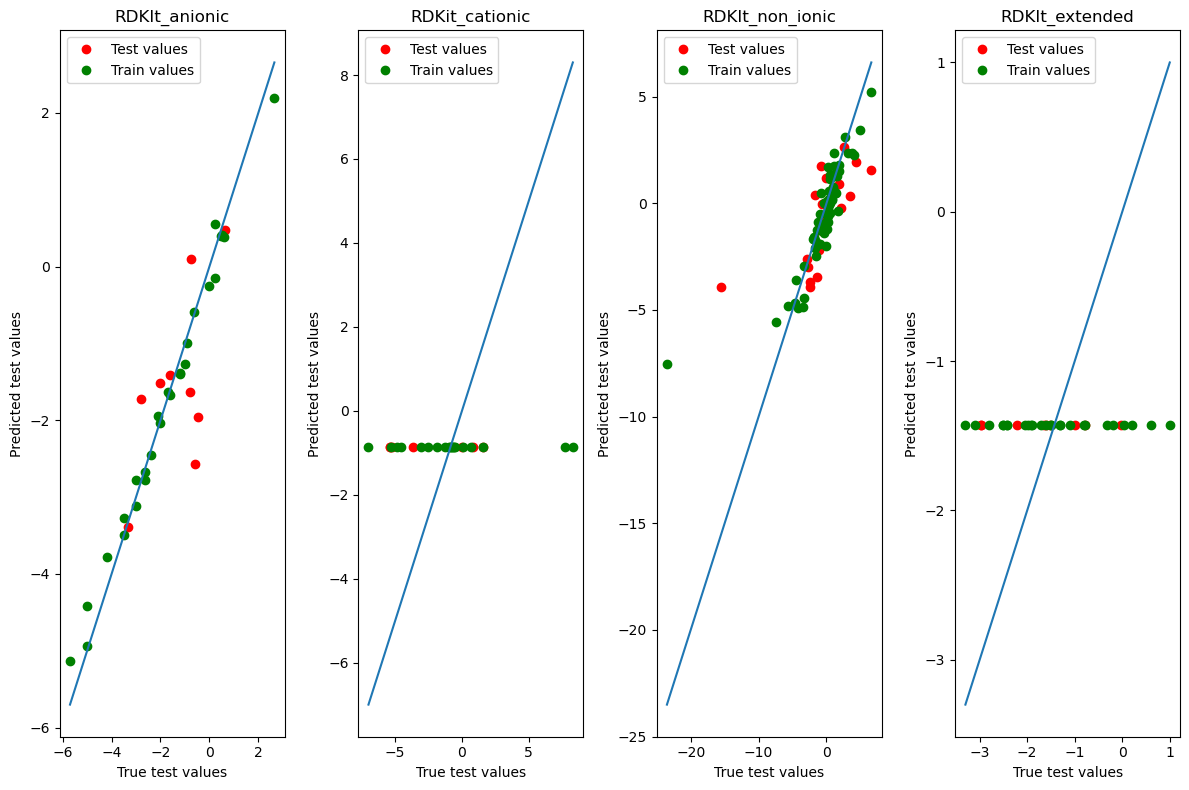

In [17]:
calculate_to_score(LGBMRegressor(verbosity = -1), estimator_name='Gradient boosting', param_grid = space)

**SVM**

In [18]:
space = {'svr__C':hp.loguniform('C', -2*np.log(10), 1*np.log(10)),
         'svr__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svr__degree':hp.choice('degree', [2,3,4]),
         'svr__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svr__coef0':hp.loguniform('coef0', -1, 1)}


100%|████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.85trial/s, best loss: 1.2649121592177086]
{'C': 8.82588747501636, 'coef0': 1.1121886364692848, 'degree': 1, 'gamma': 1, 'kernel': 0}
100%|█████████████████████████████████████████████████| 50/50 [00:04<00:00, 10.01trial/s, best loss: 2.191436741286341]
{'C': 5.752939590125008, 'coef0': 1.9791769694990669, 'degree': 0, 'gamma': 0, 'kernel': 0}
100%|█████████████████████████████████████████████████| 50/50 [00:06<00:00,  8.20trial/s, best loss: 1.342265755583671]
{'C': 0.015082446203887703, 'coef0': 0.5909033059574486, 'degree': 0, 'gamma': 1, 'kernel': 2}
100%|████████████████████████████████████████████████| 50/50 [00:05<00:00,  9.12trial/s, best loss: 0.5667253479984641]
{'C': 4.7789938361469835, 'coef0': 0.6432082305471454, 'degree': 2, 'gamma': 0, 'kernel': 3}


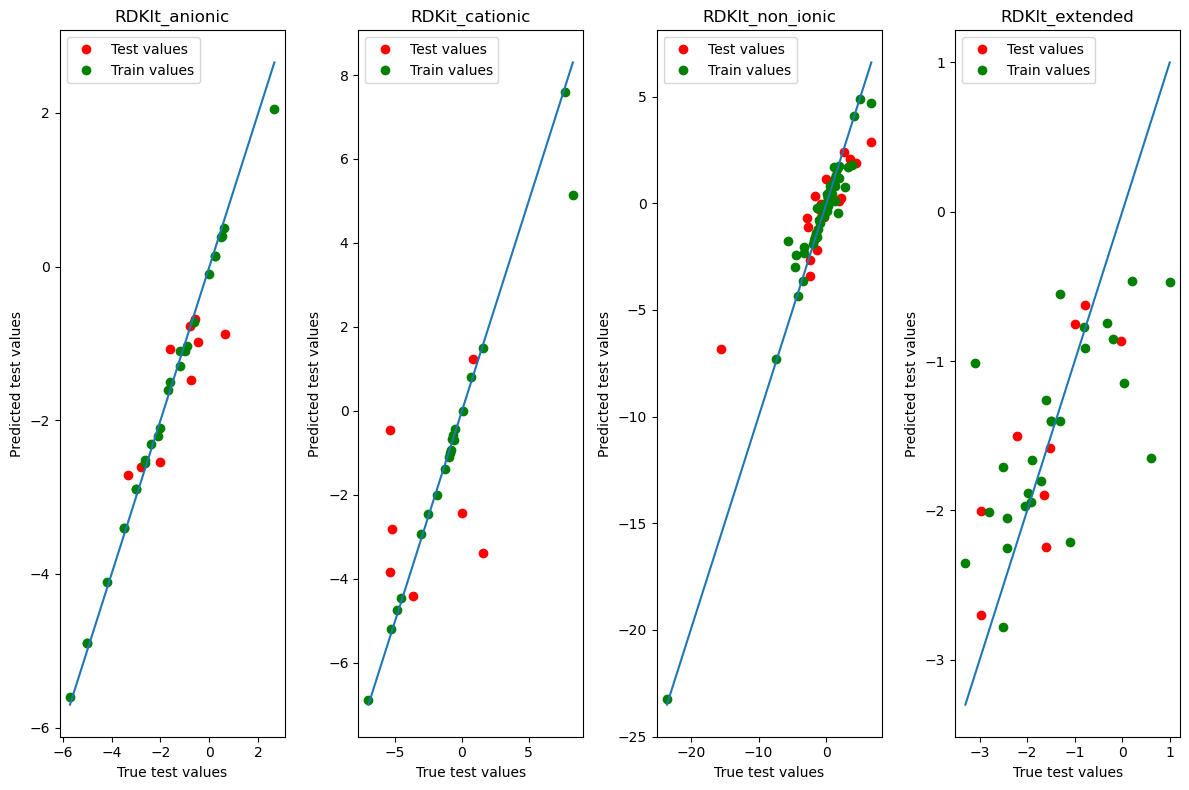

In [19]:
calculate_to_score(SVR(max_iter = 15000), estimator_name = 'SVR', param_grid = space)
                                                                


**KNearestneighbors**

In [20]:
space = {
    'kneighborsregressor__n_neighbors': hp.randint('n_neighbors', 3, 16),  # Увеличил диапазон
    'kneighborsregressor__weights': hp.choice('weights', ['uniform', 'distance']),
    'kneighborsregressor__metric': hp.choice('metric', ['minkowski', 'euclidean', 'manhattan']),  # Упростил выбор
    'kneighborsregressor__p': hp.uniform('p', 1, 3),  # Параметр для minkowski
    'kneighborsregressor__algorithm': hp.choice('algorithm', ['auto', 'ball_tree', 'kd_tree']),
    'kneighborsregressor__leaf_size': hp.randint('leaf_size', 10, 50)  # Для tree-based алгоритмов
}

100%|████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.72trial/s, best loss: 1.1084740900620647]
{'algorithm': 2, 'leaf_size': 18, 'metric': 2, 'n_neighbors': 4, 'p': 1.5418666102989054, 'weights': 1}
100%|████████████████████████████████████████████████| 50/50 [00:05<00:00,  9.66trial/s, best loss: 2.3632573268926302]
{'algorithm': 0, 'leaf_size': 25, 'metric': 0, 'n_neighbors': 12, 'p': 2.9051046934992235, 'weights': 1}
100%|█████████████████████████████████████████████████| 50/50 [00:06<00:00,  8.03trial/s, best loss: 1.635836224271382]
{'algorithm': 2, 'leaf_size': 34, 'metric': 0, 'n_neighbors': 7, 'p': 1.330603016544044, 'weights': 1}
100%|████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.82trial/s, best loss: 0.7549558333333334]
{'algorithm': 2, 'leaf_size': 27, 'metric': 0, 'n_neighbors': 4, 'p': 1.6282486268135856, 'weights': 0}


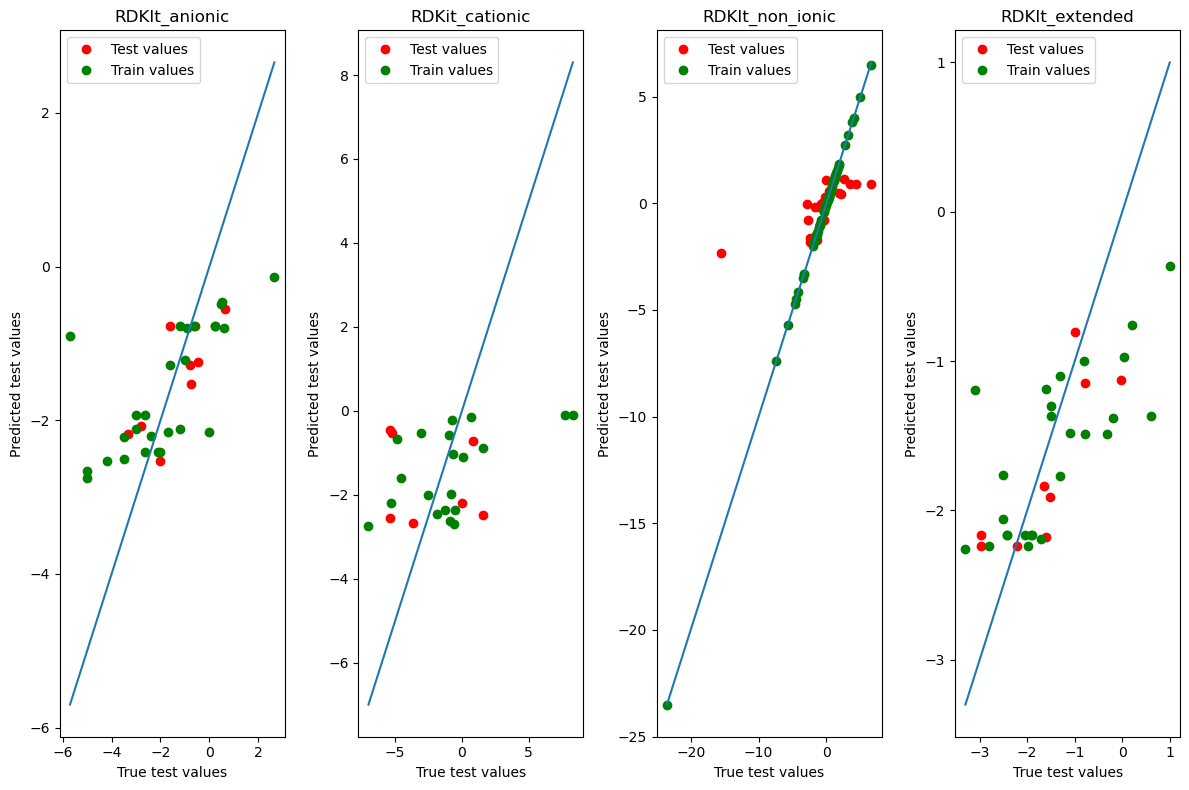

In [21]:
calculate_to_score(KNeighborsRegressor(), estimator_name='KMeans', param_grid=space)

Let's save results into pickle file and show the final scores model in readable format

In [22]:
with open('scores_rdkit_descs.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [23]:
pd.DataFrame(scores['RDKIt_anionic'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,-0.201583,1.412735,1.463884,0.739819,0.599800,0.472939,1.000000,0.000004,0.000003
1,RDKit,Random Forest,0.009476,1.545024,1.394872,0.413832,0.900285,0.742491,0.370163,1.551495,1.174391
2,RDKit,Gradient boosting,-0.264230,1.554997,1.482602,0.283756,0.995175,0.791167,0.982882,0.255779,0.197273
3,RDKit,SVR,0.226458,1.264912,1.311261,0.674806,0.670564,0.523233,0.993989,0.151564,0.117326
4,RDKit,KMeans,0.324686,1.108474,1.267490,0.545579,0.792680,0.732948,0.405082,1.507873,1.111791


In [24]:
pd.DataFrame(scores['RDKit_cationic'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,0.111517,2.447292,1.848374,-0.100990,3.066918,2.367685,0.999944,0.027069,0.021630
1,RDKit,Random Forest,0.108316,2.315760,1.850037,-0.385457,3.440385,3.071178,-0.003696,3.631253,2.401824
2,RDKit,Gradient boosting,-0.064006,2.525528,1.933587,-0.297533,3.329428,3.039700,0.000000,3.624561,2.368233
3,RDKit,SVR,0.133714,2.191437,1.836720,-0.067737,3.020248,2.484914,0.961254,0.713461,0.253090
4,RDKit,KMeans,0.057214,2.363257,1.875992,-0.327562,3.367735,3.049894,0.184030,3.274104,2.402424


In [25]:
pd.DataFrame(scores['RDKIt_non_ionic'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,0.632472,1.444592,1.519440,0.726357,2.169338,1.536700,0.942753,0.911169,0.679297
1,RDKit,Random Forest,0.300034,1.522508,1.784966,0.305930,3.454912,2.002242,0.375127,3.010353,1.323625
2,RDKit,Gradient boosting,0.309956,1.458672,1.778607,0.428446,3.135191,1.920156,0.660439,2.219118,0.953658
3,RDKit,SVR,0.625940,1.342266,1.526146,0.666123,2.396231,1.486678,0.944372,0.898187,0.515982
4,RDKit,KMeans,0.239207,1.635836,1.822541,0.302434,3.463602,2.011999,1.000000,0.000000,0.000000


In [26]:
pd.DataFrame(scores['RDKIt_extended'])

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,RDKit,Linear Regression,0.196068,0.713736,0.999461,0.594695,0.585740,0.558350,0.997763,0.052697,0.043039
1,RDKit,Random Forest,0.072080,0.770342,1.035950,0.577022,0.598374,0.486374,0.563143,0.736364,0.532580
2,RDKit,Gradient boosting,-0.147455,0.812766,1.092434,-0.052142,0.943737,0.760400,0.000000,1.114096,0.905194
3,RDKit,SVR,0.083076,0.566725,1.032868,0.635169,0.555725,0.460061,0.427001,0.843334,0.588661
4,RDKit,KMeans,0.195892,0.754956,0.999516,0.598515,0.582973,0.482958,0.444355,0.830465,0.650896
